# LeetCode #1011: Capacity To Ship Packages Within D Days

https://leetcode.com/problems/capacity-to-ship-packages-within-d-days/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (try every capacity)** | $O(n \cdot \text{sum})$ | $O(1)$ |
| **Optimal: Binary Search on Ship Capacity ★** | $O(n \log(\text{sum}))$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (try every capacity)
Try every capacity from $\max(\text{weights})$ to $\text{sum}(\text{weights})$. For each, simulate loading packages greedily and return the first capacity that works in $\le$ days. $O(n \cdot \text{sum})$ — too slow when sum approaches $5 \times 10^4 \times 500 = 2.5 \times 10^7$.

### Optimal: Binary Search on Ship Capacity ★
Binary search the capacity in $[\max(\text{weights}), \text{sum}(\text{weights})]$. For a candidate capacity $c$, simulate greedily: load packages until the next would exceed $c$, then start a new day. Count days; if $\le D$, $c$ is feasible. Monotone feasibility → binary search → $O(n \log(\text{sum}))$.

**Why this is better than Brute Force:** Binary search eliminates almost all candidates — $O(\log(\text{sum}))$ checks instead of $O(\text{sum})$ linear scan.

**Constraints:**
* $1 \le \text{weights.length} \le 5 \times 10^4$
* $1 \le \text{weights}[i] \le 500$
* $1 \le \text{days} \le 5 \times 10^4$


## Solutions

### C#

In [ ]:
public int ShipWithinDays(int[] weights, int days) {
    int lo = weights.Max(), hi = weights.Sum();
    while (lo < hi) {
        int mid = lo + (hi - lo) / 2;
        // Simulate loading: count days needed at capacity mid
        int d = 1, cur = 0;
        foreach (int w in weights) {
            if (cur + w > mid) { d++; cur = 0; }
            cur += w;
        }
        // If feasible within D days, try lower capacity
        if (d <= days) hi = mid;
        else lo = mid + 1;
    }
    return lo;
}


### Python

In [ ]:
def ship_within_days(weights: list[int], days: int) -> int:
    lo, hi = max(weights), sum(weights)
    while lo < hi:
        mid = lo + (hi - lo) // 2
        # Simulate loading: count days needed at capacity mid
        d, cur = 1, 0
        for w in weights:
            if cur + w > mid:
                d += 1
                cur = 0
            cur += w
        # If feasible within D days, try lower capacity
        if d <= days:
            hi = mid
        else:
            lo = mid + 1
    return lo


### Go

In [ ]:
func shipWithinDays(weights []int, days int) int {
    lo, hi := slices.Max(weights), 0
    for _, w := range weights { hi += w }
    for lo < hi {
        mid := lo + (hi-lo)/2
        // Simulate loading: count days needed at capacity mid
        d, cur := 1, 0
        for _, w := range weights {
            if cur+w > mid { d++; cur = 0 }
            cur += w
        }
        // If feasible within D days, try lower capacity
        if d <= days { hi = mid } else { lo = mid + 1 }
    }
    return lo
}


### Rust

In [ ]:
pub fn ship_within_days(weights: Vec<i32>, days: i32) -> i32 {
    let (mut lo, mut hi) = (
        *weights.iter().max().unwrap(),
        weights.iter().sum::<i32>(),
    );
    while lo < hi {
        let mid = lo + (hi - lo) / 2;
        // Simulate loading: count days needed at capacity mid
        let (mut d, mut cur) = (1, 0);
        for &w in &weights {
            if cur + w > mid { d += 1; cur = 0; }
            cur += w;
        }
        // If feasible within D days, try lower capacity
        if d <= days { hi = mid; } else { lo = mid + 1; }
    }
    lo
}


## Example Scenarios

**1. Common Case**
**Input:** weights = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], days = 5
lo=10, hi=55. Binary search converges to 15. At mid=15: [1+2+3+4+5=15✓, 6+7=13, +8=21>15→day 2; 6+7=13; +8=21>15→new day: 6+7=13, 8+9=17>15→day 3; 8; 8+9=17>15→day 4: 8, 9+10=19>15→5th day: 9,10]. Verifying 15: split into 5 days each ≤15. ≤5 days → hi=15.

**2. Slightly Complex**
**Input:** weights = [3, 2, 2, 4, 1, 4], days = 3
lo=4, hi=16. Binary search converges to 6. At mid=6: [3+2=5, +2=7>6→day 2; 2+4=6✓; 1+4=5≤6] → 3 days ≤ 3 → hi=6. At mid=5: [3+2=5, +2=7>5→day2; 2+4=6>5→day3; 4+1=5, +4=9>5→day4] → 4>3 → lo=6. Answer: 6.

**3. Edge Case: Time Factor**
**Input:** weights = [1, 2, …, 500] × 100 (50000 weights), days = 1
lo = 500, hi = sum ≈ 12.5M. days=1 → must ship all in one day → answer=hi. Binary search: any cap < sum fails (more than 1 day) → lo keeps rising → converges to hi in $\log_2(12.5M) \approx 24$ iterations.

**4. Edge Case: Space Factor**
**Input:** weights = [500, 500, ..., 500] (50000 elements), days = 50000
lo=500, hi=25M. days=50000 means 1 package/day works → answer=500. Variables: lo, hi, mid, d, cur — 5 integers. No auxiliary storage.

**5. Almost-Impossible but Plausible**
**Input:** weights = [1, 1, 1, ..., 1, 500] (49999 ones then 500), days = 2
Must include 500 on its own day (since 500 is max). Other day has 49999 ones. lo=500, hi≈50499. At mid=25249: day1=[499ones=499≤25249?, in fact all 49999 ones fit in one day at cap 25249→1 day; day2=500] → 2 days ≤ 2 → hi=25249. But can we go lower? At mid=500: day1=[1s: 500×1=500→500, next 1→501>500→day2; 1+1+...=500 per day; but we have 49999 ones → 100 days just for ones] > 2 → lo=501. Converges to some value where all 49999 ones fit in 1 day plus 500 on day 2.


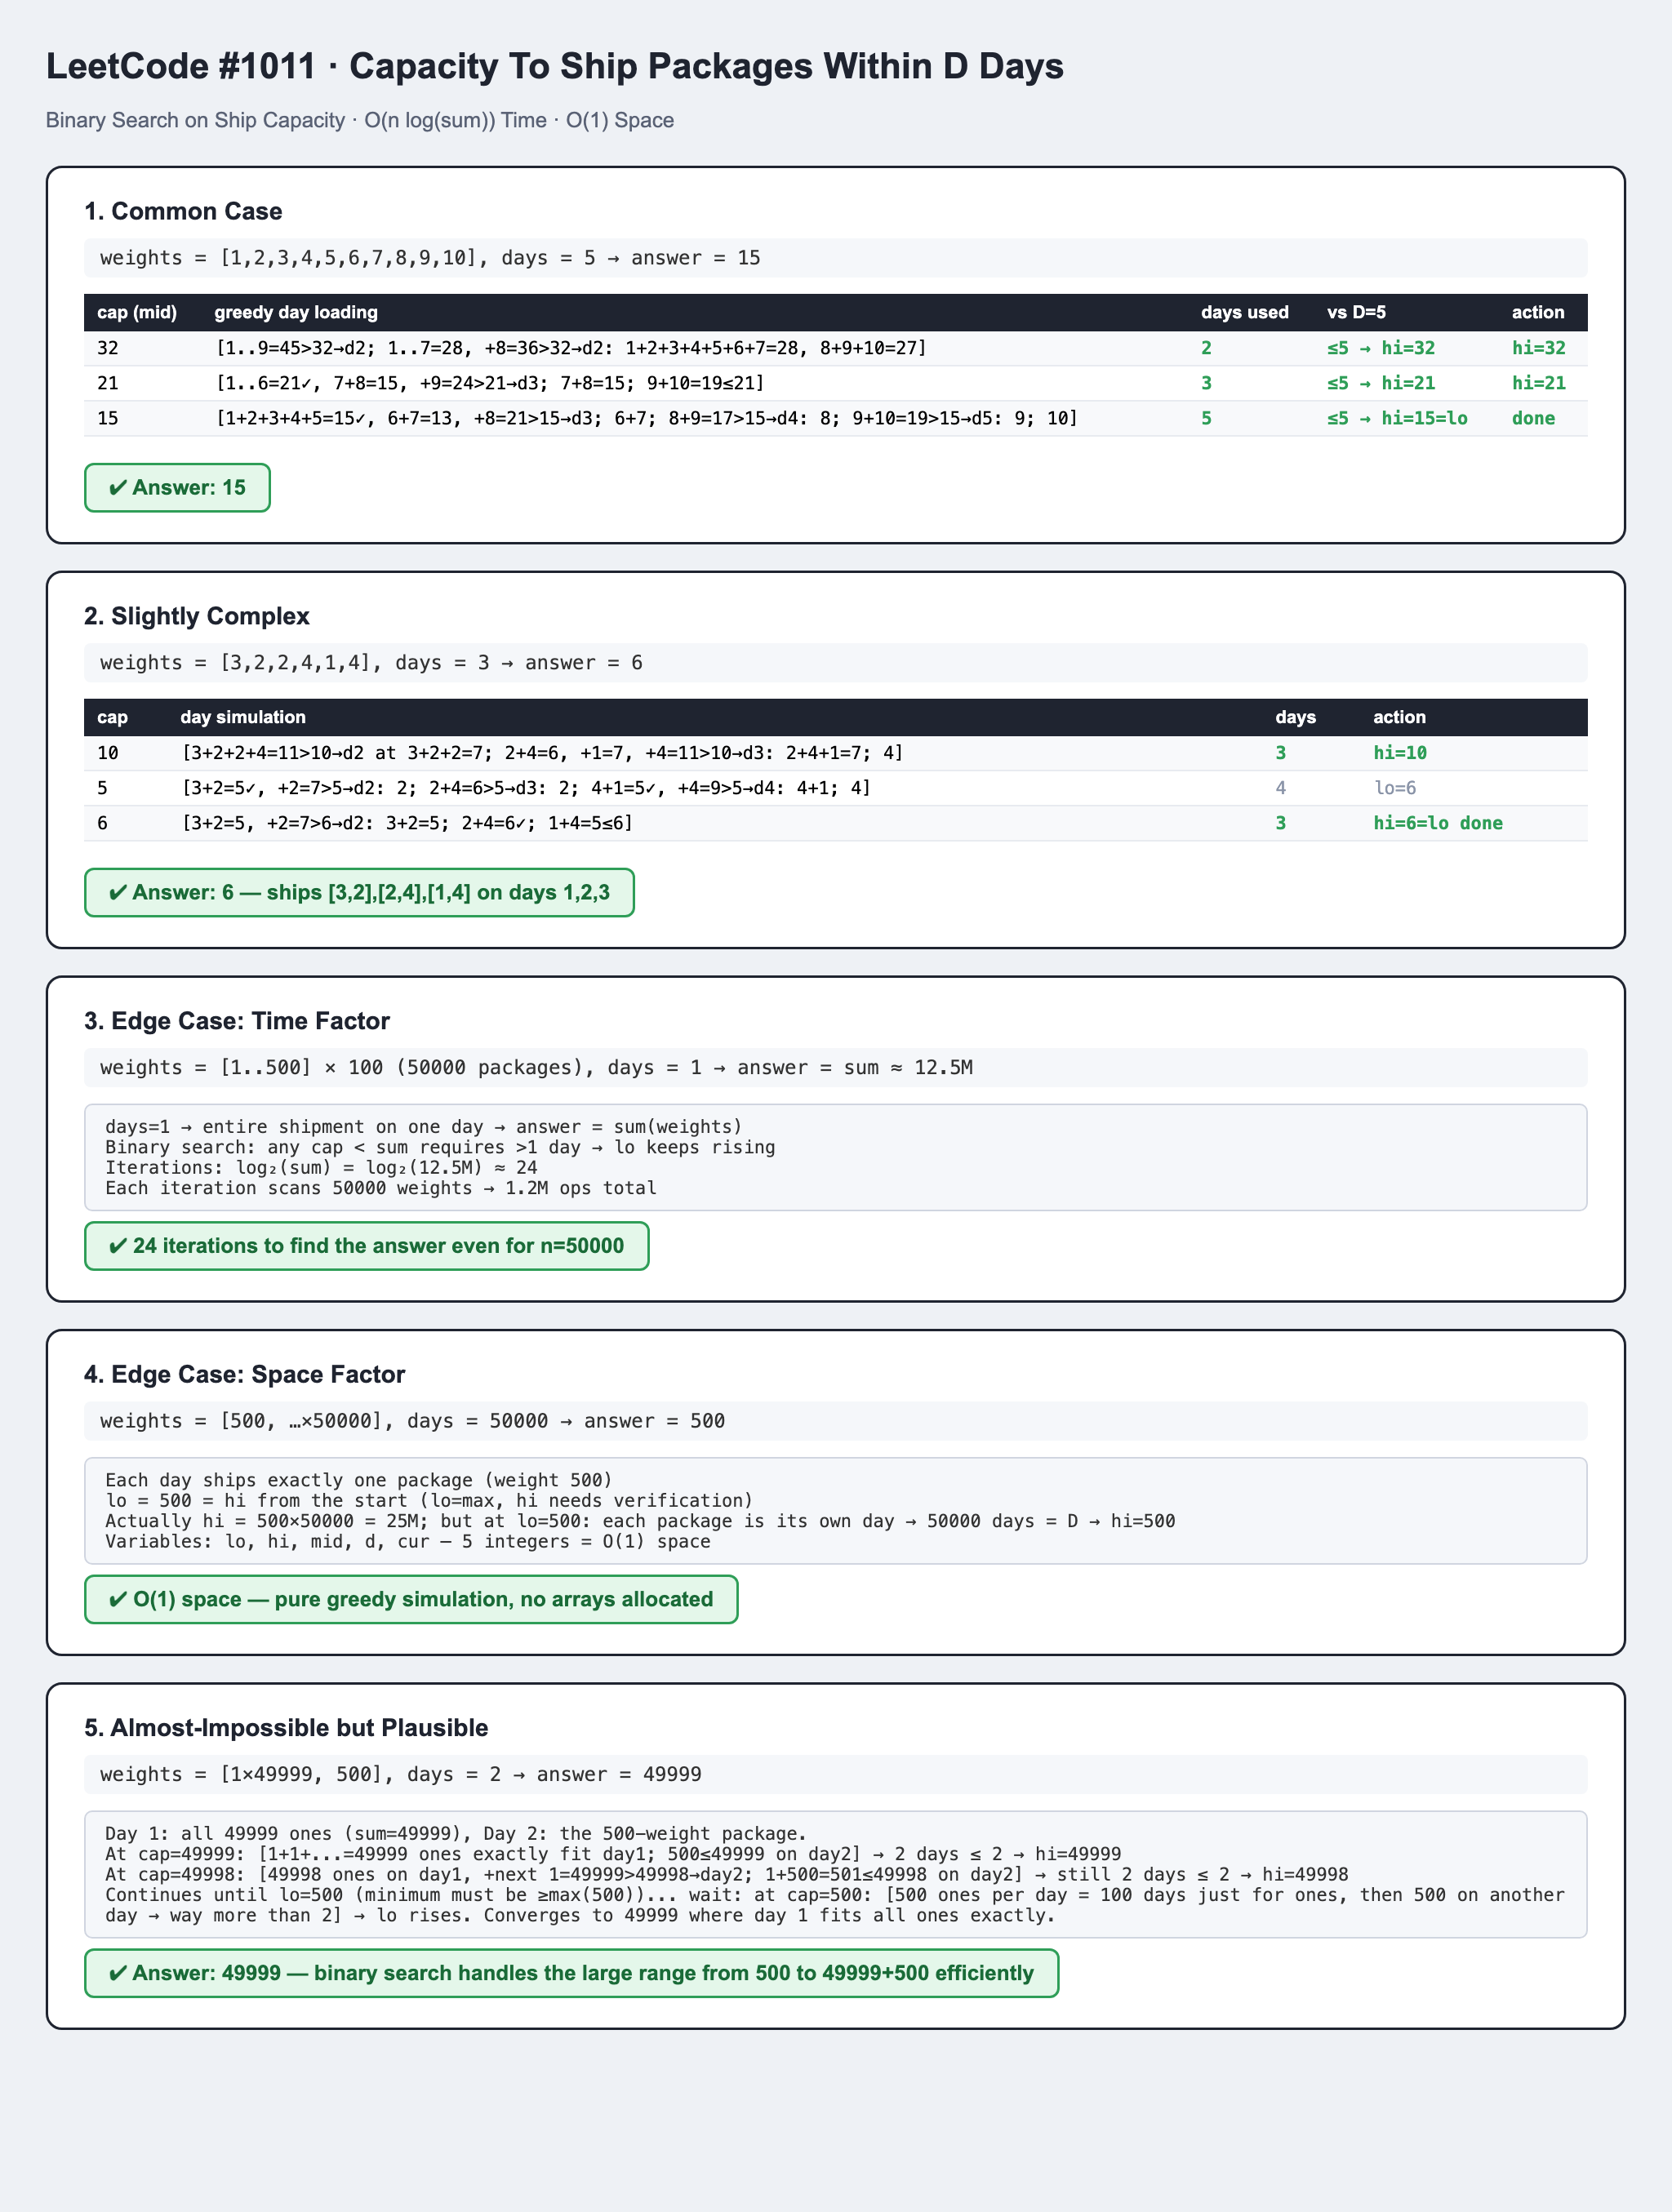